In [ ]:
import pandas as pd

df_train_results = pd.read_csv("df_train_results.csv")

print(df_train_results.shape)
print(df_train_results.columns)
df_train_results.head()

(254792, 38)
Index(['transaction type', 'merchant_category', 'transaction_status',
       'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
       'receiver_bank', 'device_type', 'network_type', 'hour_of_day',
       'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount',
       'night_transaction', 'senior_sender', 'senior_high_amount',
       'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk',
       'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour',
       'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'actual',
       'predicted', 'probability', 'prob_rf_calibrated', 'pred_rf_calibrated',
       'risk_bucket_calibrated', 'transaction_notes', 'fraud_text_flag'],
      dtype='object')


,transaction type,merchant_category,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,...,p2p_odd_hour,senior_odd_hour,actual,predicted,probability,prob_rf_calibrated,pred_rf_calibrated,risk_bucket_calibrated,transaction_notes,fraud_text_flag
0,0,4,1,2,1,1,2,6,0,1,...,0,0,0,0,0.054622,0.009121,0,Low Risk,Zomato food order.,0
1,1,5,1,0,2,9,6,6,0,1,...,0,0,0,0,0.036917,0.004604,0,Low Risk,Payment to milkman.,0
2,2,6,0,1,3,5,2,2,2,1,...,0,0,0,0,0.047378,0.007103,0,Low Risk,Petrol for bike.,0
3,1,5,1,0,1,0,2,6,0,1,...,0,0,0,0,0.095927,0.023656,0,Low Risk,Office coffee split.,0
4,0,0,1,0,2,3,3,0,0,0,...,0,0,0,0,0.137082,0.185978,0,Medium Risk,Zomato food order.,0


In [ ]:
df = df_train_results.copy()

text_col = "transaction_notes"
target_col = "actual"

# Columns to exclude from tabular input
exclude_cols = [
    text_col,
    target_col,
    "predicted",
    "probability",
    "pred_rf_calibrated",
    "risk_bucket_calibrated",
    "fraud_text_flag"
]

tabular_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

print("Tabular columns:", len(tabular_cols))
print(tabular_cols)

Tabular columns: 31
['transaction type', 'merchant_category', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'hour_of_day', 'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount', 'night_transaction', 'senior_sender', 'senior_high_amount', 'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk', 'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour', 'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'prob_rf_calibrated']


In [ ]:
import numpy as np

tabular_data = df[tabular_cols].values

texts = df[text_col].astype(str).tolist()

labels = df[target_col].values

print(tabular_data.shape)
print(len(texts))
print(labels.shape)

(254792, 31)
254792
(254792,)


In [ ]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

text_embeddings = text_model.encode(
    texts,
    batch_size=512,
    show_progress_bar=True
)

print(text_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/498 [00:00<?, ?it/s]

(254792, 384)


In [ ]:
from sklearn.model_selection import train_test_split

X_tab_train, X_tab_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(

    tabular_data,
    text_embeddings,
    labels,

    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
import torch

X_tab_train = torch.tensor(
    X_tab_train,
    dtype=torch.float32
)

X_text_train = torch.tensor(
    X_text_train,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1)

X_tab_test = torch.tensor(
    X_tab_test,
    dtype=torch.float32
)

X_text_test = torch.tensor(
    X_text_test,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1,1)

In [ ]:
import torch.nn as nn

class MultiModalMLP(nn.Module):

    def __init__(self,
                 tabular_dim,
                 text_dim):

        super().__init__()

        self.tabular_net = nn.Sequential(

            nn.Linear(tabular_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.text_net = nn.Sequential(

            nn.Linear(text_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.combined_net = nn.Sequential(

            nn.Linear(64 + 128, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self,
                tabular,
                text):

        tab_out = self.tabular_net(tabular)

        text_out = self.text_net(text)

        combined = torch.cat(
            (tab_out, text_out),
            dim=1
        )

        output = self.combined_net(
            combined
        )

        return output

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MultiModalMLP(
    X_tab_train.shape[1],
    X_text_train.shape[1]
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20
batch_size = 512

for epoch in range(epochs):

    model.train()

    permutation = torch.randperm(
        X_tab_train.size()[0]
    )

    epoch_loss = 0

    for i in range(
        0,
        X_tab_train.size()[0],
        batch_size
    ):

        indices = permutation[i:i+batch_size]

        batch_tab = X_tab_train[indices].to(device)
        batch_text = X_text_train[indices].to(device)
        batch_labels = y_train[indices].to(device)

        optimizer.zero_grad()

        outputs = model(
            batch_tab,
            batch_text
        )

        loss = criterion(
            outputs,
            batch_labels
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}"
    )

Epoch 1, Loss: 86.8009
Epoch 2, Loss: 47.1569
Epoch 3, Loss: 43.9746
Epoch 4, Loss: 44.5233
Epoch 5, Loss: 43.9115
Epoch 6, Loss: 43.1220
Epoch 7, Loss: 38.8620
Epoch 8, Loss: 38.3874
Epoch 9, Loss: 40.7619
Epoch 10, Loss: 38.3758
Epoch 11, Loss: 36.7101
Epoch 12, Loss: 35.6773
Epoch 13, Loss: 35.9571
Epoch 14, Loss: 34.1438
Epoch 15, Loss: 33.7137
Epoch 16, Loss: 33.0013
Epoch 17, Loss: 34.2785
Epoch 18, Loss: 33.1644
Epoch 19, Loss: 32.5622
Epoch 20, Loss: 32.3302


In [ ]:
torch.save(
    model.state_dict(),
    "multimodal_mlp_model.pth"
)

print("Model saved successfully")

Model saved successfully


In [ ]:
model.eval()

with torch.no_grad():

    logits = model(
        X_tab_test.to(device),
        X_text_test.to(device)
    )

    probs = torch.sigmoid(logits)

mlp_probs = probs.cpu().numpy()

In [ ]:
import pandas as pd

pd.DataFrame({
    "mlp_prob": mlp_probs.flatten()
}).to_csv(
    "mlp_probabilities.csv",
    index=False
)

In [ ]:
mlp_preds = (mlp_probs > 0.5).astype(int)


===== MLP Evaluation Results =====

Accuracy : 0.9720952137993288
Precision: 0.9408904810644831
Recall   : 0.9380102040816326
F1-score : 0.9394481349003577
ROC-AUC  : 0.9884049737142745

===== Classification Report =====

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     39199
         1.0       0.94      0.94      0.94     11760

    accuracy                           0.97     50959
   macro avg       0.96      0.96      0.96     50959
weighted avg       0.97      0.97      0.97     50959


===== Confusion Matrix =====

[[38506   693]
 [  729 11031]]


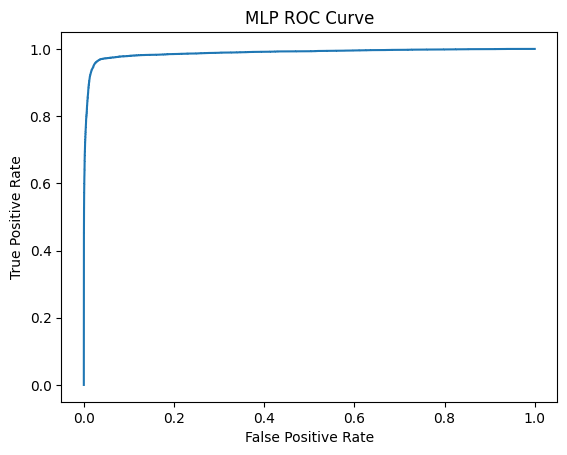


Evaluation results saved as mlp_test_results.csv


In [ ]:
# ===== IMPORT METRICS =====

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===== GENERATE PREDICTIONS =====

model.eval()

with torch.no_grad():

    logits = model(
        X_tab_test.to(device),
        X_text_test.to(device)
    )

    probs = torch.sigmoid(logits)

mlp_probs = probs.cpu().numpy()

# Binary predictions
mlp_preds = (mlp_probs > 0.5).astype(int)

y_true = y_test.cpu().numpy()


# ===== METRICS =====

accuracy = accuracy_score(y_true, mlp_preds)

precision = precision_score(y_true, mlp_preds)

recall = recall_score(y_true, mlp_preds)

f1 = f1_score(y_true, mlp_preds)

roc_auc = roc_auc_score(y_true, mlp_probs)


# ===== PRINT RESULTS =====

print("\n===== MLP Evaluation Results =====\n")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-score :", f1)

print("ROC-AUC  :", roc_auc)


# ===== CLASSIFICATION REPORT =====

print("\n===== Classification Report =====\n")

print(
    classification_report(
        y_true,
        mlp_preds
    )
)


# ===== CONFUSION MATRIX =====

cm = confusion_matrix(
    y_true,
    mlp_preds
)

print("\n===== Confusion Matrix =====\n")

print(cm)


# ===== ROC CURVE =====

fpr, tpr, _ = roc_curve(
    y_true,
    mlp_probs
)

plt.figure()

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MLP ROC Curve")

plt.show()


# ===== SAVE RESULTS =====

eval_results = pd.DataFrame({

    "actual": y_true.flatten(),

    "mlp_prob": mlp_probs.flatten(),

    "mlp_pred": mlp_preds.flatten()

})

eval_results.to_csv(
    "mlp_test_results.csv",
    index=False
)

print("\nEvaluation results saved as mlp_test_results.csv")

## **Training improved version**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
df_train_results = pd.read_csv('/content/df_train_results.csv')

In [ ]:
# Define tabular features (exclude text and targets)
exclude_cols = [
    "transaction_notes", "actual", "predicted", "probability",
    "prob_rf_calibrated", "pred_rf_calibrated", "risk_bucket_calibrated",
    "fraud_text_flag", "hybrid_prob_alpha_0.03", "hybrid_prob_alpha_0.05",
    "hybrid_prob_alpha_0.07", "hybrid_prob_alpha_0.1",
    "risk_bucket_hybrid_0.03", "risk_bucket_hybrid_0.05",
    "risk_bucket_hybrid_0.07", "risk_bucket_hybrid_0.1",
    "hybrid_probability", "risk_bucket_final", "hybrid_predicted",
    "rf_predicted_optimal"
]

tabular_cols = [col for col in df_train_results.columns if col not in exclude_cols]

# Extract features and target
X = df_train_results[tabular_cols].values.astype(np.float32)
y = df_train_results["actual"].values.astype(np.float32)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

In [ ]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)  # Output logit
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
input_dim = X_train.shape[1]
model = FraudMLP(input_dim).to(device)

# Handle class imbalance
pos_weight = torch.tensor([(len(y_train) - y_train.sum()) / y_train.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
num_epochs = 20
best_f1 = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)

    model.eval()
    val_preds = []
    val_targets = []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            probs = torch.sigmoid(logits)
            val_preds.extend(probs.cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_preds_bin = (np.array(val_preds) >= 0.5).astype(int)
    f1 = f1_score(val_targets, val_preds_bin)

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = model.state_dict()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_dataset):.4f}, Val F1: {f1:.4f}")

# Load best model
model.load_state_dict(best_model_state)
print("Training complete. Best F1 on validation:", best_f1)

Epoch 1/20, Loss: 0.4608, Val F1: 0.8672
Epoch 2/20, Loss: 0.3856, Val F1: 0.8860
Epoch 3/20, Loss: 0.3660, Val F1: 0.8852
Epoch 4/20, Loss: 0.3506, Val F1: 0.8936
Epoch 5/20, Loss: 0.3391, Val F1: 0.8985
Epoch 6/20, Loss: 0.3279, Val F1: 0.9002
Epoch 7/20, Loss: 0.3219, Val F1: 0.9017
Epoch 8/20, Loss: 0.3132, Val F1: 0.9031
Epoch 9/20, Loss: 0.3084, Val F1: 0.9067
Epoch 10/20, Loss: 0.3053, Val F1: 0.9096
Epoch 11/20, Loss: 0.3036, Val F1: 0.9116
Epoch 12/20, Loss: 0.2975, Val F1: 0.9135
Epoch 13/20, Loss: 0.2930, Val F1: 0.9172
Epoch 14/20, Loss: 0.2920, Val F1: 0.9178
Epoch 15/20, Loss: 0.2866, Val F1: 0.9189
Epoch 16/20, Loss: 0.2858, Val F1: 0.9178
Epoch 17/20, Loss: 0.2824, Val F1: 0.9202
Epoch 18/20, Loss: 0.2827, Val F1: 0.9178
Epoch 19/20, Loss: 0.2788, Val F1: 0.9224
Epoch 20/20, Loss: 0.2785, Val F1: 0.9177
Training complete. Best F1 on validation: 0.9223721262556214


In [ ]:
df_test_results = pd.read_csv("/content/df_test_results.csv")

In [ ]:
X_test = df_test_results[tabular_cols].values.astype(np.float32)
X_test = scaler.transform(X_test)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits).cpu().numpy()

# Add to test dataframe
df_test_results["mlp_prob_improved"] = test_probs

In [ ]:
from sklearn.metrics import classification_report, f1_score

# Model in eval mode
model.eval()

# Prepare test features
X_test = df_test_results[tabular_cols].values.astype(np.float32)
X_test = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()

# Store improved MLP probabilities
df_test_results["mlp_prob_improved"] = probs

# Choose threshold = 0.5 for evaluation (we can optimize later)
y_pred_mlp = (probs >= 0.5).astype(int)
y_true = df_test_results["actual"].values

# Classification report
print("===== IMPROVED MLP ONLY =====")
print(classification_report(y_true, y_pred_mlp, digits=4))

# F1-score for fraud class specifically
f1_fraud = f1_score(y_true, y_pred_mlp)
print(f"Fraud F1-score: {f1_fraud:.4f}")

===== IMPROVED MLP ONLY =====
              precision    recall  f1-score   support

           0     0.9950    0.9688    0.9817     48998
           1     0.3333    0.7625    0.4639      1002

    accuracy                         0.9647     50000
   macro avg     0.6642    0.8656    0.7228     50000
weighted avg     0.9818    0.9647    0.9714     50000

Fraud F1-score: 0.4639


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

probs = df_test_results["mlp_prob_improved"].values
y_true = df_test_results["actual"].values

best_thresh = 0
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)

for thresh in thresholds:
    y_pred = (probs >= thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}, Best Fraud F1: {best_f1:.4f}")

Best threshold: 0.66, Best Fraud F1: 0.5054


In [ ]:
mlp_alpha = 0.4  # start with small weight
df_test_results["hybrid_mlp_prob"] = (
    df_test_results["hybrid_probability"] * (1 - mlp_alpha) +
    df_test_results["mlp_prob_improved"] * mlp_alpha
)

# Apply optimal threshold
y_pred_hybrid_mlp = (df_test_results["hybrid_mlp_prob"] >= best_thresh).astype(int)

from sklearn.metrics import classification_report
print("===== HYBRID (RF + Keywords + Improved MLP) =====")
print(classification_report(y_true, y_pred_hybrid_mlp, digits=4))

===== HYBRID (RF + Keywords + Improved MLP) =====
              precision    recall  f1-score   support

           0     0.9949    0.9771    0.9860     48998
           1     0.4036    0.7565    0.5264      1002

    accuracy                         0.9727     50000
   macro avg     0.6993    0.8668    0.7562     50000
weighted avg     0.9831    0.9727    0.9767     50000



In [ ]:
mlp_model_path = "improved_mlp_fraud.pth"
torch.save(model.state_dict(), mlp_model_path)
print(f"MLP model saved to {mlp_model_path}")

MLP model saved to improved_mlp_fraud.pth


In [ ]:
# Use the same 30 columns as training MLP
trained_tabular_cols = tabular_cols.copy()  # save training columns somewhere

# Make sure to use these columns on test data
X_test = df_test_results[trained_tabular_cols].values.astype(np.float32)

In [ ]:
len(trained_tabular_cols)

30

In [ ]:
trained_tabular_cols

['transaction type',
 'merchant_category',
 'transaction_status',
 'sender_age_group',
 'receiver_age_group',
 'sender_state',
 'sender_bank',
 'receiver_bank',
 'device_type',
 'network_type',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'txn_day',
 'txn_month',
 'high_amount',
 'night_transaction',
 'senior_sender',
 'senior_high_amount',
 'amount_zscore',
 'night_high_txn',
 'bank_risk',
 'network_risk',
 'amount_per_hour',
 'is_p2p',
 'is_senior',
 'is_odd_hour',
 'large_p2p_transfer',
 'p2p_odd_hour',
 'senior_odd_hour']